# EDA 보강 — earnings · analyst 심화 (B) + news · reddit 간단히 (C 참고용)

- 구간: `01_b_eda.ipynb` 와 같음 — train 전체 (대상일 ~2026-02-12), 원본은 train 전용 `dataset_train/`. 마지막 대상일 cutoff 전까지만 읽음.
- "밤사이 창" = 기준일 16:00 ~ 대상일 09:30 (cutoff). 대상일 시가 전에 알 수 있는 정보.
- news · reddit 은 C 담당. 여기선 양, 시간, 누수 주의점, 다음 날 수익률과의 대략적 관계만 보고 C 에게 넘김.
- Reddit `score`, `n_comments` 는 36시간 뒤 값이라 읽지도 않음.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "work" / "b"))
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)

from src import Dataset, START
from src.data import CUTOFF

ds = Dataset(folder=ROOT / "dataset_train")          # train 전용 원본 (val 없음)
b = pd.read_parquet(ROOT / "work/b/cache/b_features_train.parquet")
b["label"] = b.label.astype(int); b["absret"] = b.ret_pct.abs()
b["up"] = (b.label >= 3).astype(int); b["big"] = b.label.isin([0, 4]).astype(int)
tr = b.copy()                                         # train 전체
EDA_END = tr.target.max(); UNTIL = EDA_END + CUTOFF
print(f"EDA 구간 {len(tr):,}행, 대상일 {tr.target.min():%Y-%m-%d} ~ {EDA_END:%Y-%m-%d}, 원본은 {UNTIL} 전까지")

# 밤사이 창: 기준일 16:00 ~ 대상일 09:30
NS = "datetime64[ns]"
win = tr[["date", "target"]].drop_duplicates().sort_values("date")
win = pd.DataFrame({"lo": (win.date + pd.Timedelta(hours=16)).astype(NS), "hi": (win.target + CUTOFF).astype(NS),
                    "target": win.target.astype(NS)}).sort_values("lo").reset_index(drop=True)

def to_window(ts):
    '''시각 → 그 시각이 들어가는 밤사이 창의 대상일 (없으면 NaT). 입력 순서대로 돌려줌.'''
    t = pd.Series(pd.to_datetime(np.asarray(ts))).astype(NS)
    s = pd.DataFrame({"t": t, "pos": np.arange(len(t))}).dropna().sort_values("t")
    m = pd.merge_asof(s, win, left_on="t", right_on="lo")
    ok = (m.t < m.hi).values
    out = np.full(len(t), np.datetime64("NaT"), dtype=NS)
    out[m.pos.values[ok]] = m.target.values[ok]
    return out

tr["target"] = tr.target.astype(NS); tr["date"] = tr.date.astype(NS)

def sp(x, y):
    ok = x.notna() & y.notna()
    return x[ok].corr(y[ok], method="spearman") if ok.sum() > 30 else np.nan

def daily_ic(df, x, y):
    r = df[["date", x, y]].dropna()
    rx, ry = r.groupby("date")[x].rank(), r.groupby("date")[y].rank()
    t = pd.DataFrame({"date": r.date, "a": rx, "b": ry})
    ic = t.groupby("date").apply(lambda g: g.a.corr(g.b) if g.a.nunique() > 1 else np.nan, include_groups=False).dropna()
    return ic.mean(), ic.mean() / ic.std() * np.sqrt(len(ic)), len(ic)

EDA 구간 18,800행, 대상일 2024-08-14 ~ 2026-02-12, 원본은 2026-02-12 09:30:00 전까지


# A. earnings (B)
## A-1. 발표 시각별 반응

In [2]:
e = ds.table("earnings", since=START, until=UNTIL)
e["target"] = to_window(e.known_at)
hm = e.known_at.dt.hour * 60 + e.known_at.dt.minute
e["when"] = np.where(hm >= 16 * 60, "장 마감 후", np.where(hm < 9 * 60 + 30, "개장 전", "장중"))
ev = e.dropna(subset=["target"]).merge(tr, on=["symbol", "target"], how="inner")
g = ev.groupby("when")
print(pd.DataFrame({"n": g.size(), "|ret| 평균": g.absret.mean(), "급등락%": g.big.mean() * 100,
                    "gap 부호 적중%": g.apply(lambda d: (np.sign(d.gap) == np.sign(d.ret_pct)).mean() * 100, include_groups=False),
                    "|gap| 평균%": g.gap.apply(lambda s: s.abs().mean() * 100)}).round(2))
print("\n장중 발표(1건)는 대상일 창 밖이라 earn_now 에 안 잡힘:", int((e.when == "장중").sum()), "건")

          n  |ret| 평균   급등락%  gap 부호 적중%  |gap| 평균%
when                                               
개장 전    168      3.81  55.95       79.76       2.96
장 마감 후  129      5.92  74.42       82.17       4.67

장중 발표(1건)는 대상일 창 밖이라 earn_now 에 안 잡힘: 1 건


## A-2. 서프라이즈 크기·부호와 반응
서프라이즈 부호와 다음 날 수익률 부호가 얼마나 맞는지, 크기와 |수익률| 관계. 이미 시간외 gap 에 반영된 몫을 빼고 보기 위해 '장중 추가 움직임'(ret − gap)도 봄.

In [3]:
ev["s"] = ev.surprise_pct.clip(-100, 100)
ev["intra"] = ev.ret_pct / 100 - ev.gap          # 개장 후 추가로 움직인 몫 (근사)
ev["s_bin"] = pd.cut(ev.s, [-101, -10, 0, 5, 15, 101], labels=["< −10%", "−10~0", "0~5", "5~15", "> 15%"])
g = ev.groupby("s_bin", observed=True)
print(pd.DataFrame({"n": g.size(), "ret 평균%": g.ret_pct.mean(), "상승%": g.up.mean() * 100, "급등락%": g.big.mean() * 100,
                    "gap 평균%": g.gap.mean() * 100, "장중 추가 평균%": g.intra.mean() * 100}).round(2))
print(f"\nSpearman(surprise, ret) {sp(ev.s, ev.ret_pct):.3f} | (surprise, gap) {sp(ev.s, ev.gap):.3f} | "
      f"(surprise, 장중 추가) {sp(ev.s, ev.intra):.3f} | (gap, 장중 추가) {sp(ev.gap, ev.intra):.3f}")
print("서프라이즈 부호 = ret 부호:", round((np.sign(ev.s) == np.sign(ev.ret_pct)).mean() * 100, 1), "%",
      "| gap 부호 = ret 부호:", round((np.sign(ev.gap) == np.sign(ev.ret_pct)).mean() * 100, 1), "%")

          n  ret 평균%    상승%   급등락%  gap 평균%  장중 추가 평균%
s_bin                                                 
< −10%   12    -1.15  41.67  58.33    -0.71      -0.44
−10~0    27    -1.23  29.63  62.96    -0.91      -0.33
0~5     116    -0.46  35.34  61.21    -0.26      -0.19
5~15     85     1.76  60.00  64.71     1.55       0.21
> 15%    56     0.83  53.57  71.43     0.51       0.33



Spearman(surprise, ret) 0.236 | (surprise, gap) 0.248 | (surprise, 장중 추가) 0.103 | (gap, 장중 추가) 0.057
서프라이즈 부호 = ret 부호: 52.5 % | gap 부호 = ret 부호: 80.8 %


## A-3. 후보 피처: 종목별 과거 실적 반응 크기
각 실적 발표 날, 그 종목의 **이전** 실적 발표 다음날 |수익률| 평균(cutoff 이전만). 새 종목도 일봉 과거가 같은 길이라 계산 가능. 2023-10 부터의 일봉으로 이전 반응을 구함.

In [4]:
e_all = ds.table("earnings", since="2023-10-01", until=UNTIL)
d_all = ds.table("daily", since="2023-10-01", until=UNTIL, columns=["symbol", "date_et", "ret"])
d_all["date_et"] = d_all.date_et.astype(NS)
days_all = np.sort(d_all.date_et.unique())
# 반응일: 09:30 이후(장중·장 마감 후) 발표 → 다음 거래일, 09:30 전 발표 → 그날
kt = e_all.known_at
day0 = kt.dt.normalize().astype(NS).values
after = ((kt.dt.hour * 60 + kt.dt.minute) >= 9 * 60 + 30).values
pos = np.where(after, np.searchsorted(days_all, day0, side="right"), np.searchsorted(days_all, day0, side="left"))
react = np.full(len(pos), np.datetime64("NaT"), dtype=NS)
react[pos < len(days_all)] = days_all[pos[pos < len(days_all)]]
e_all["react"] = react
e_all = e_all.merge(d_all.rename(columns={"date_et": "react"}), on=["symbol", "react"], how="left")
e_all["absr"] = e_all.ret.abs() * 100
e_all = e_all.sort_values(["symbol", "react"])
e_all["hist_absr"] = e_all.groupby("symbol").absr.transform(lambda s: s.shift().expanding().mean())
e_all["hist_n"] = e_all.groupby("symbol").absr.transform(lambda s: s.shift().expanding().count())
x = ev.merge(e_all[["symbol", "react", "hist_absr", "hist_n"]].rename(columns={"react": "target"}), on=["symbol", "target"], how="left")
x = x[x.hist_n >= 2]
print(f"이전 반응 2회 이상 있는 실적일 {len(x)}건")
print(f"Spearman(과거 실적 반응 평균, 이번 |ret|) {sp(x.hist_absr, x.absret):.3f} | "
      f"(atr14, 이번 |ret|) {sp(x.atr14, x.absret):.3f} | (|gap_z|, 이번 |ret|) {sp(x.abs_gap_z, x.absret):.3f}")
x["h_q"] = pd.qcut(x.hist_absr, 3, labels=["하", "중", "상"])
g = x.groupby("h_q", observed=True)
print(pd.DataFrame({"n": g.size(), "과거 반응 평균%": g.hist_absr.mean(), "이번 |ret|%": g.absret.mean(), "급등락%": g.big.mean() * 100}).round(2))

이전 반응 2회 이상 있는 실적일 295건
Spearman(과거 실적 반응 평균, 이번 |ret|) 0.362 | (atr14, 이번 |ret|) 0.228 | (|gap_z|, 이번 |ret|) 0.509
      n  과거 반응 평균%  이번 |ret|%   급등락%
h_q                                 
하    99       2.24       3.11  47.47
중    98       4.33       4.68  71.43
상    98       7.80       6.34  72.45


# B. analyst (B)
## B-1. 밤사이 새 의견이 있는 날 — 실적일과 겹침을 나눠서

In [5]:
a = ds.table("analyst", since=START, until=UNTIL)
a["target"] = to_window(a.known_at)
na = a.dropna(subset=["target"]).copy()
ta = na.target_action.fillna("").str.lower()
na["net"] = (na.action == "up").astype(int) + (ta == "raises") - (na.action == "down") - (ta == "lowers")
agg = na.groupby(["symbol", "target"]).agg(an_n=("net", "size"), an_net=("net", "sum"),
                                           an_up=("action", lambda s: (s == "up").sum()), an_down=("action", lambda s: (s == "down").sum())).reset_index()
y = tr.merge(agg, on=["symbol", "target"], how="left").fillna({"an_n": 0, "an_net": 0, "an_up": 0, "an_down": 0})
y["has"] = np.where(y.an_n > 0, "의견 있음", "없음")
y["earn"] = np.where(y.earn_now == 1, "실적일", "실적 아닌 날")
g = y.groupby(["earn", "has"])
print(pd.DataFrame({"n": g.size(), "|ret| 평균": g.absret.mean(), "급등락%": g.big.mean() * 100}).round(2))
print("\n밤사이 의견의", round(agg.merge(tr[["symbol", "target", "earn_now"]], on=["symbol", "target"]).earn_now.mean() * 100, 1), "% 가 실적일")

                   n  |ret| 평균   급등락%
earn    has                          
실적 아닌 날 없음     17417      1.29  12.57
        의견 있음   1086      1.52  16.67
실적일     없음       274      4.55  62.77
        의견 있음     23      6.77  78.26

밤사이 의견의 2.1 % 가 실적일


## B-2. 의견 방향과 다음 날 수익률 (실적 아닌 날만)

In [6]:
z = y[(y.earn_now == 0) & (y.an_n > 0)].copy()
z["dir"] = np.sign(z.an_net)
g = z.groupby("dir")
print(pd.DataFrame({"n": g.size(), "ret 평균%": g.ret_pct.mean(), "상승%": g.up.mean() * 100,
                    "gap 평균%": g.gap.mean() * 100, "ret−gap 평균%": (g.ret_pct.mean() - g.gap.mean() * 100)}).round(2))
up_, dn_ = z[z.an_up > 0], z[z.an_down > 0]
print(f"\n등급 상향 {len(up_)}건: ret 평균 {up_.ret_pct.mean():+.2f}%, gap 평균 {up_.gap.mean() * 100:+.2f}%")
print(f"등급 하향 {len(dn_)}건: ret 평균 {dn_.ret_pct.mean():+.2f}%, gap 평균 {dn_.gap.mean() * 100:+.2f}%")
print(f"Spearman(an_net, ret) {sp(z.an_net, z.ret_pct):.3f} | (an_net, gap) {sp(z.an_net, z.gap):.3f} | (an_net, ret−gap) {sp(z.an_net, z.ret_pct / 100 - z.gap):.3f}")

        n  ret 평균%    상승%  gap 평균%  ret−gap 평균%
dir                                            
-1.0  308     0.41  38.64     0.15         0.26
 0.0  142    -0.01  37.32     0.02        -0.03
 1.0  636     0.32  38.36     0.15         0.16

등급 상향 30건: ret 평균 +1.08%, gap 평균 +0.85%
등급 하향 31건: ret 평균 +0.32%, gap 평균 -0.24%
Spearman(an_net, ret) 0.040 | (an_net, gap) 0.036 | (an_net, ret−gap) 0.056


# C. news (C 참고용)
## C-1. 양과 시간

In [7]:
nw = ds.table("news", since=START, until=UNTIL, columns=["known_at", "symbols", "tone", "positive", "negative"])
print(f"기사 {len(nw):,}건 (EDA 구간). known_at 분 단위 분포:", nw.known_at.dt.minute.value_counts().head(4).to_dict())
print("시각(시) 분포 상위:", nw.known_at.dt.hour.value_counts().sort_index().to_dict())
k = nw.symbols.fillna("").str.count(",") + 1
print("기사당 종목 수:", k.describe()[["mean", "50%", "max"]].round(1).to_dict(), "| 종목 태그 없음:", int((nw.symbols.fillna("") == "").sum()))
nw["target"] = to_window(nw.known_at)
print("밤사이 창(기준일 16:00 ~ 대상일 09:30)에 들어간 기사 비율:", round(nw.target.notna().mean() * 100, 1), "%")
print("tone 분포:", nw.tone.describe()[["mean", "std", "min", "50%", "max"]].round(2).to_dict())

기사 2,405,233건 (EDA 구간). known_at 분 단위 분포: {30: 606298, 45: 605301, 0: 601390, 15: 592244}
시각(시) 분포 상위: {0: 52209, 1: 54069, 2: 58383, 3: 61517, 4: 66622, 5: 75191, 6: 88190, 7: 99508, 8: 112698, 9: 130311, 10: 144759, 11: 154105, 12: 155847, 13: 150358, 14: 144717, 15: 132026, 16: 124200, 17: 118000, 18: 109663, 19: 96745, 20: 85973, 21: 73486, 22: 61714, 23: 54942}


기사당 종목 수: {'mean': 1.4, '50%': 1.0, 'max': 60.0} | 종목 태그 없음: 0


밤사이 창(기준일 16:00 ~ 대상일 09:30)에 들어간 기사 비율: 66.7 %
tone 분포: {'mean': 0.36, 'std': 3.07, 'min': -29.17, '50%': 0.64, 'max': 27.36}


## C-2. 종목별 밤사이 기사 수·논조와 다음 날 수익률
`news_ratio` = 밤사이 기사 수 / 그 종목의 직전 20 기준일 평균 (과거만 사용). 실적일은 기사가 몰리므로 나눠서 봄.

In [8]:
o = nw.dropna(subset=["target"]).assign(symbol=lambda d: d.symbols.fillna("").str.split(",")).explode("symbol")
o = o[o.symbol.isin(set(tr.symbol))]
agg = o.groupby(["symbol", "target"]).agg(news_n=("tone", "size"), news_tone=("tone", "mean"), news_neg=("negative", "mean")).reset_index()
w = tr.merge(agg, on=["symbol", "target"], how="left").fillna({"news_n": 0}).sort_values(["symbol", "target"])
w["news_ratio"] = w.news_n / w.groupby("symbol").news_n.transform(lambda s: s.shift().rolling(20, min_periods=10).mean()).replace(0, np.nan)
print("밤사이 기사 수 (종목·날): 중앙값", w.news_n.median(), "| 평균", round(w.news_n.mean(), 1), "| 0건 비율", round((w.news_n == 0).mean() * 100, 1), "%")
print("실적일 평균 기사 수", round(w[w.earn_now == 1].news_n.mean(), 1), "vs 평소", round(w[w.earn_now == 0].news_n.mean(), 1))
rows = []
for name, part in [("전체", w), ("실적 아닌 날", w[w.earn_now == 0])]:
    for f, y_ in [("news_tone", "ret_pct"), ("news_neg", "ret_pct"), ("news_ratio", "absret"), ("news_n", "absret")]:
        ic, t, n = daily_ic(part, f, y_)
        rows.append({"구간": name, "피처": f, "대상": "방향(ret)" if y_ == "ret_pct" else "크기(|ret|)", "날짜 IC": ic, "t": t})
print(pd.DataFrame(rows).round(3).to_string(index=False))
q = w[w.earn_now == 0].dropna(subset=["news_ratio"])
q["r_q"] = pd.qcut(q.news_ratio.rank(method="first"), 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
g = q.groupby("r_q", observed=True)
print("\n실적 아닌 날, news_ratio 5분위"); print(pd.DataFrame({"기사 비율 평균": g.news_ratio.mean(), "급등락%": g.big.mean() * 100, "|ret| 평균": g.absret.mean(), "|gap_z| 평균": g.abs_gap_z.mean()}).round(2))
print(f"\nSpearman(news_ratio, |gap_z|) {sp(q.news_ratio, q.abs_gap_z):.3f} — 시간외 갭과 겹치는 정도")

밤사이 기사 수 (종목·날): 중앙값 14.0 | 평균 94.7 | 0건 비율 16.6 %
실적일 평균 기사 수 132.6 vs 평소 94.1


     구간         피처        대상  날짜 IC      t
     전체  news_tone   방향(ret)  0.008  0.880
     전체   news_neg   방향(ret) -0.006 -0.784
     전체 news_ratio 크기(|ret|)  0.069  8.317
     전체     news_n 크기(|ret|)  0.086 11.968
실적 아닌 날  news_tone   방향(ret)  0.005  0.526
실적 아닌 날   news_neg   방향(ret) -0.003 -0.372
실적 아닌 날 news_ratio 크기(|ret|)  0.049  6.114
실적 아닌 날     news_n 크기(|ret|)  0.078 10.633

실적 아닌 날, news_ratio 5분위
     기사 비율 평균   급등락%  |ret| 평균  |gap_z| 평균
r_q                                       
Q1       0.15  10.71      1.19        0.28
Q2       0.48  13.97      1.32        0.28
Q3       0.72  14.24      1.37        0.30
Q4       1.09  14.36      1.38        0.33
Q5       3.03  15.07      1.44        0.40

Spearman(news_ratio, |gap_z|) 0.107 — 시간외 갭과 겹치는 정도


# D. reddit (C 참고용)
종목 구분이 없는 시황 데이터 → 날짜 단위(337일)로만 볼 수 있음. `created_et` 만 읽음 (score·n_comments 는 미래 값).

In [9]:
subs = sorted({p.name.split(".")[0] for p in (ds.dir / "reddit").glob("*.parquet")})
cnt = {}
for s_ in subs:
    for kind in ["posts", "comments"]:
        t = pq.read_table(ds.dir / "reddit" / f"{s_}.{kind}.parquet", columns=["created_et"]).to_pandas().created_et
        t = t[(t >= START) & (t < UNTIL)]
        tg = pd.Series(to_window(t.reset_index(drop=True)))
        cnt[(s_, kind)] = tg.value_counts()
c = pd.DataFrame(cnt).fillna(0)
c.index = pd.to_datetime(c.index)
tot = pd.DataFrame({"posts": c.xs("posts", axis=1, level=1).sum(1), "comments": c.xs("comments", axis=1, level=1).sum(1)})
print("서브레딧별 밤사이 댓글 수 (하루 평균):", c.xs("comments", axis=1, level=1).mean().round(0).astype(int).sort_values(ascending=False).to_dict())
mk = tr.groupby("target").agg(mkt_absret=("ret_pct", lambda s: abs(s.mean())), big_share=("big", "mean"), mkt_ret=("ret_pct", "mean"),
                              mkt_gap=("mkt_gap", "first"))
m = mk.join(tot, how="left")
for col in ["posts", "comments"]:
    m[col + "_ratio"] = m[col] / m[col].shift().rolling(20, min_periods=10).mean()
print("\n날짜 단위 Spearman (n=%d일)" % len(m))
print(pd.DataFrame({c_: {"시장 |평균 ret|": sp(m[c_], m.mkt_absret), "급등락 종목 비율": sp(m[c_], m.big_share),
                          "시장 평균 ret": sp(m[c_], m.mkt_ret), "|mkt_gap|": sp(m[c_], m.mkt_gap.abs())}
                    for c_ in ["comments", "comments_ratio", "posts_ratio"]}).round(3))

서브레딧별 밤사이 댓글 수 (하루 평균): {'wallstreetbets': 22395, 'Superstonk': 3342, 'stocks': 2917, 'StockMarket': 1828, 'investing': 1750, 'Daytrading': 1714, 'ValueInvesting': 1332, 'options': 727}

날짜 단위 Spearman (n=376일)
             comments  comments_ratio  posts_ratio
시장 |평균 ret|     0.217           0.149        0.040
급등락 종목 비율       0.225           0.172        0.074
시장 평균 ret       0.060           0.043       -0.012
|mkt_gap|       0.367           0.279        0.167


# E. 발표용 그림 → `work/b/figs/05_earn_hist.png`

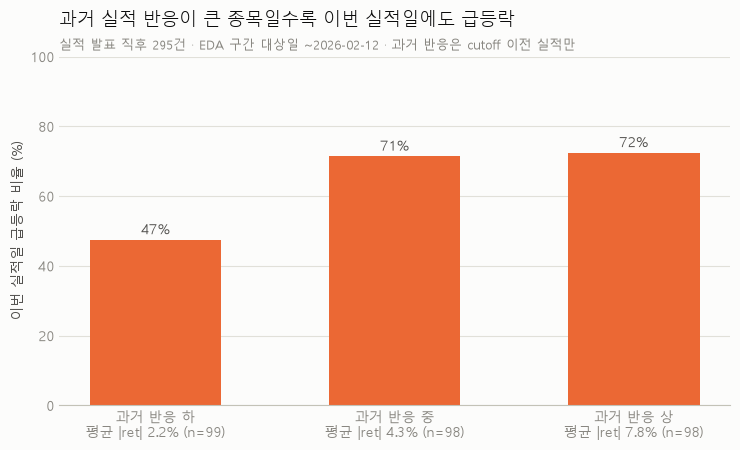

In [10]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
have = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams.update({"font.family": next((f for f in ["Malgun Gothic", "AppleGothic", "NanumGothic"] if f in have), "sans-serif"),
                     "axes.unicode_minus": False})
SURFACE, INK, INK2, MUTED, GRID, AXIS, ORANGE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#eb6834"
g = x.groupby("h_q", observed=True)
big, hist, n = g.big.mean() * 100, g.hist_absr.mean(), g.size()
fig, ax = plt.subplots(figsize=(7.5, 4.6), facecolor=SURFACE); ax.set_facecolor(SURFACE)
bars = ax.bar(range(3), big.values, width=0.55, color=ORANGE)
for r, v in zip(bars, big.values):
    ax.annotate(f"{v:.0f}%", (r.get_x() + r.get_width() / 2, v), xytext=(0, 4), textcoords="offset points", ha="center", color=INK2, fontsize=10)
ax.set_xticks(range(3), [f"과거 반응 {k}\n평균 |ret| {h:.1f}% (n={c})" for k, h, c in zip(big.index, hist.values, n.values)])
ax.set_ylim(0, 100)
ax.set_title("과거 실적 반응이 큰 종목일수록 이번 실적일에도 급등락", loc="left", color=INK, fontsize=13, pad=22)
ax.text(0, 1.02, f"실적 발표 직후 {len(x)}건 · EDA 구간 대상일 ~{EDA_END:%Y-%m-%d} · 과거 반응은 cutoff 이전 실적만", transform=ax.transAxes, color=MUTED, fontsize=9)
ax.set_ylabel("이번 실적일 급등락 비율 (%)", color=INK2)
ax.tick_params(colors=MUTED, length=0); ax.grid(axis="y", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
for s_ in ["top", "right", "left"]:
    ax.spines[s_].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
fig.tight_layout(); fig.savefig(ROOT / "work/b/figs/05_earn_hist.png", dpi=150); plt.show()